<div align="center">
  <img src="https://aiscmadrid.com/images/events/event31/img_698a0b708e8a60.03948846.webp" width="300">
</div>

# 🧠 SESIÓN 2 - BAUC3M x AISC


##📊 Interpretación de datos para decisiones reales de negocio

Imagina que estas en **enero de 2023**.

Te encuentras asesorando a un cliente, y te pide que le aconsejes dónde invertir **10,000€**:

- Apple
- Microsoft
- Nvidia
- Tesla
- O simplemente el mercado (SPY)

**¿Qué le aconsejarías?**

Hoy vamos a comprobar si vuestra decisión habría sido buena… usando datos reales

##📊 De intuición a datos

Nuestra intuición puede estar sesgada por noticias, opiniones o tendencias.

Vamos a usar datos reales de mercado para analizar qué ocurrió realmente.

Pero antes de todo...

¿Quién cree que Nvidia fue la mejor inversión?
¿Quién diría Tesla?
¿Quién elegiría el mercado por seguridad?

## Objetivos:

- Identificar oportunidades con mayor potencial

- Comparar alternativas de forma estructurada

- Evaluar riesgos antes de asignar recursos

- Tomar decisiones fundamentadas y defendibles

##¡EMPECEMOS!

# **1. Importación de librerías**
##Preparando nuestro entorno de análisis:

Con estas líneas estamos activando las herramientas que nos permiten analizar datos reales.

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# **2. Descarga de datos de mercado**

##Accedemos a los datos de mercado

Compararemos empresas individuales frente al mercado global (SPY) para entender qué implica elegir una apuesta concreta frente a una estrategia más diversificada.

Esto es el histórico diario de precios de cada empresa. Cada fila es un día real de mercado

In [ ]:

tickers = ["AAPL", "MSFT", "SPY", "TSLA", "NVDA"]

datos = yf.download(tickers, start="2023-01-01", end="2024-01-01", auto_adjust=True)["Close"] # Close marca el cierre del mercado cada día

round(datos.head(),2) #Round simplemente por facilidad de lectura

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,MSFT,NVDA,SPY,TSLA
Date,,,,,
2023-01-03,123.10,233.45,14.30,366.07,108.10
2023-01-04,124.37,223.24,14.73,368.90,113.64
2023-01-05,123.05,216.62,14.25,364.68,110.34
2023-01-06,127.57,219.18,14.84,373.05,113.06
2023-01-09,128.10,221.31,15.61,372.84,119.77


💡 Lo que antes requería informes y bases de datos privadas,
hoy se puede obtener en segundos con Python.

* **¿Cuántos datos creéis que tenemos para cada empresa en un año?**

# **3. Exploración inicial de los datos**
##¿Quién ganó realmente en 2023?

Nos familiarizamos con los datos antes de analizarlos.
Incluso datos con similares estadísticas, pueden pertencer a realidades muy distintas



Visualizamos cómo ha evolucionado cada activo

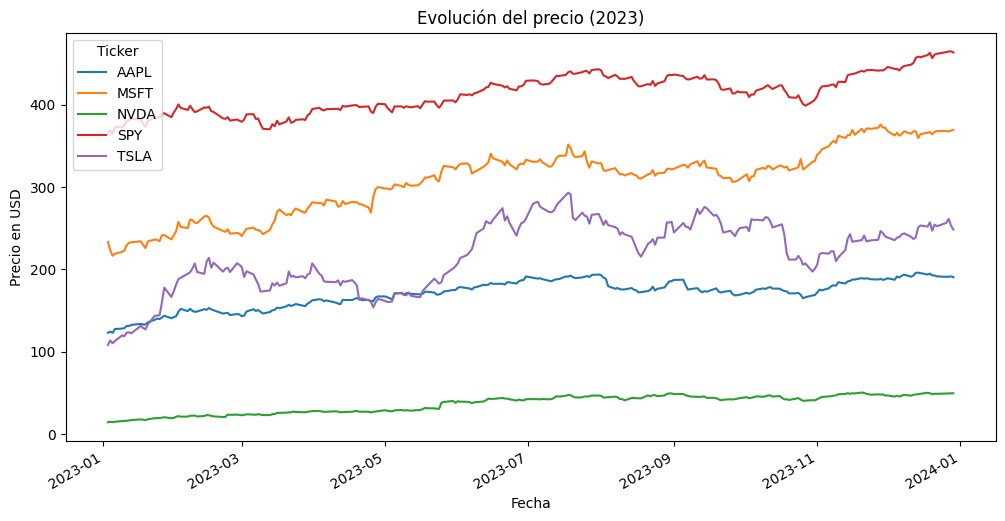

In [ ]:
datos.plot(figsize=(12,6))
plt.title("Evolución del precio (2023)")
plt.ylabel("Precio en USD")
plt.xlabel("Fecha")
plt.show()

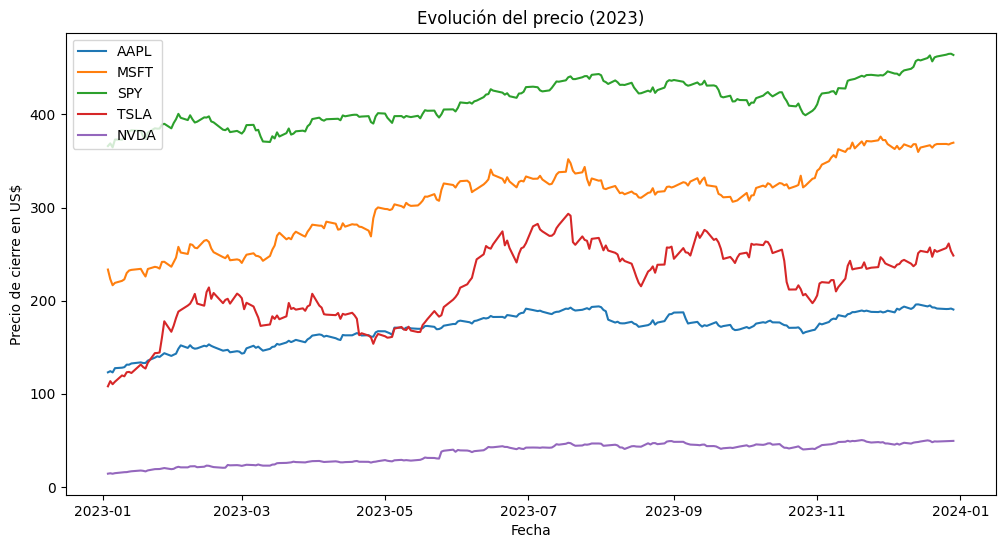

In [ ]:
plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(datos.index, datos[ticker], label=ticker)
    #Se traduce a que para cada "Ticker" Seleccionado anteriormente, creamos una linea en la grafica
    plt.xlabel("Fecha") #Etiquetas de eje
    plt.ylabel("Precio de cierre en US$")
    plt.title("Evolución del precio (2023)")
    plt.legend()

plt.show()

¿Quién parece haber crecido más?
> Responde aquí

¿Cuál parece más estable?

> Responde aquí

¿Cuál os daría más tranquilidad como inversores?

> Responde aquí

# **4.  Cálculo de rendimientos díarios**

##¿Cuál fue el mejor y el peor día de cada acción?



Vamos a medir cuánto cambia cada acción día a día en porcentaje


| Día       | Rendimiento |
| --------- | ----------- |
| Dia 1     | +5%         |
| Dia 2    | −2%         |
| Dia 3 | +3%         |


Un +5% hoy y un -2% mañana no se cancelan: se multiplican. Por eso el día a día importa

In [ ]:
rendimientos = datos.pct_change() #pct_change es una funcion que mide el cambio de datos respecto a la fila anterior
rendimientos = rendimientos.dropna() #Borra las filas con datos inexistentes
rendimientos_porc = round(rendimientos *100, 2) #Lo ponemos en base 1, para ser porcentuales
rendimientos_porc.head()
# Convertimos los números a TEXTO (string) y le sumamos el símbolo '%'
tabla_final = rendimientos_porc.astype(str) + '%'

tabla_final.head()


Ticker,AAPL,MSFT,NVDA,SPY,TSLA
Date,,,,,
2023-01-04,1.03%,-4.37%,3.03%,0.77%,5.12%
2023-01-05,-1.06%,-2.96%,-3.28%,-1.14%,-2.9%
2023-01-06,3.68%,1.18%,4.16%,2.29%,2.47%
2023-01-09,0.41%,0.97%,5.18%,-0.06%,5.93%
2023-01-10,0.45%,0.76%,1.8%,0.7%,-0.77%


- **Si tu inversión cae -6% en un día, ¿vendes o aguantas?**

Todo esto está muy bien en porcentajes… vamos a traducirlo a algo que todos entendemos: dinero.

#**5. Impacto acumulado de una decisión de inversión**
##¿Qué habría pasado con tu dinero?

Una de las preguntas clave en inversión es:

> “Si hubiese invertido 10000 dólares el primer día… ¿cuánto valdría hoy?”

Para ello usamos los rendimientos diarios (subidas y bajadas en %) y simulamos que el dinero se reinvierte cada día.

Si empiezas con **10 000 dólares**, su evolución sería:

| Día   | Rendimiento | Factor | Valor                |
| ----- | ----------- | ------ | -------------------- |
| Día 1 | +5%         | 1.05   | 10000 × 1.05 = 10500   |
| Día 2 | −2%         | 0.98   | 10500 × 0.98 = 10290  |
| Día 3 | +3%         | 1.03   | 10290 × 1.03 = 10590 |


💡 Python nos permite convertir decisiones en simulaciones:
cambiamos una variable (activo) y medimos el impacto (valor final).

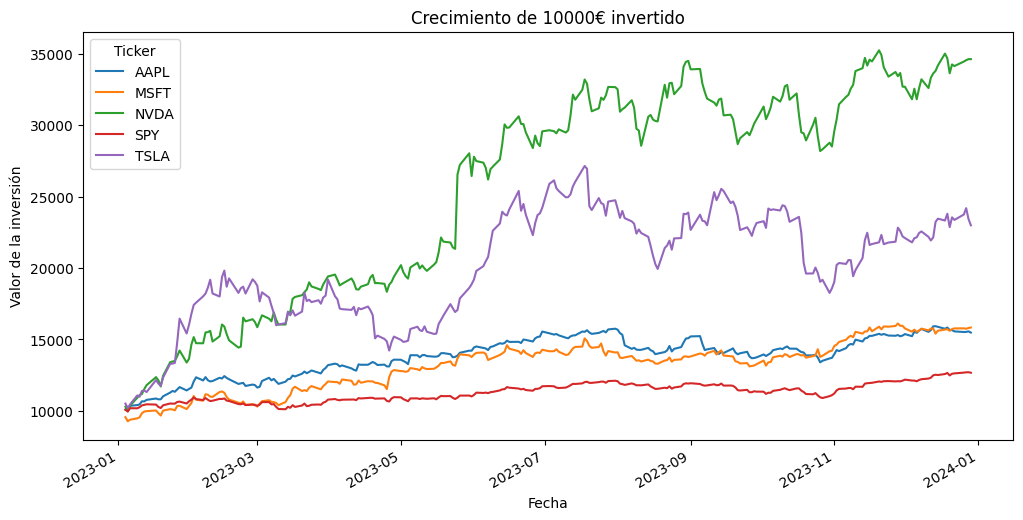

In [ ]:
rentabilidad_acumulada = (1 + rendimientos).cumprod() #.cumprod() es la formula para el interes compuesto, los multiplica sucesivamente (no suma)

rentabilidad_acumulada_cartera = 10000*(1 + rendimientos).cumprod() #Simplemente le ponemos el capital inicial

rentabilidad_acumulada_cartera.plot(figsize=(12,6)) #La propia cartera tiene de columna el valor de la inversion y de fila la fecha
plt.title("Crecimiento de 10000€ invertido")
plt.ylabel("Valor de la inversión")
plt.xlabel("Fecha")
plt.show()

💡Este proceso es replicable: mañana puedo cambiar el año, los activos o el escenario y volver a decidir con datos. Así como hoy lo aplicamos a acciones.Pero esto mismo se usa para clientes, ventas, campañas o costes: medir impacto y comparar alternativas



In [ ]:
rentabilidad_final = rentabilidad_acumulada.iloc[-1]
#iloc[-1] te da la última rentabilidad acumulada
round(rentabilidad_final, 2) #Utilizamos round para redondear

,2023-12-29
Ticker,
AAPL,1.55
MSFT,1.58
NVDA,3.46
SPY,1.27
TSLA,2.30


#### Ha ganado más quien ha invertido en NVIDIA, multiplicando su inversión por 3,46 (convertiría 1€ en 3,46€)!

💡Con Python podemos convertir una hipótesis en una prueba en 30 segundos.

# **6. ANALÍSIS DE RIESGOS**

##Ganar más no significa tomar la mejor decisión

No todas las inversiones fluctuan de la misma manera. Algunas suben y bajan mucho, otras no tanto... Vamos a medir cuánto se mueve cada activo respecto a su comportamiento habitual, lo que es decir, su **variabilidad**

> Más variación diaria = Más incertidumbre = Más riesgo

En finanzas, el riesgo se mide con una idea muy simple:

> **Cuánto varía una inversión en el tiempo**

Si un activo hoy sube +5%, mañana −4% y pasado +6%, es más arriesgado que otro que siempre se mueve entre +0.5% y −0.5%.


#### ¿Cómo se mide ese riesgo?

Vamos a usar una medida llamada **volatilidad**.

* La volatilidad es:

La desviación estándar de los rendimientos diarios.

* En términos normales:

 Mide cuánto se alejan las subidas y bajadas de lo “normal”.

| Activo | Movimientos diarios | Riesgo |
|-------|-------------------|-------|
| Fondo SPY | pequeños cambios | bajo |
| Tesla | subidas y caídas grandes | alto |

In [ ]:
riesgo = rendimientos.std() * 100 #.std corresponde a Standard Deviation (Desviación estandar), para medir volatilidad
riesgo

,0
Ticker,
AAPL,1.257004
MSFT,1.582433
NVDA,3.052478
SPY,0.824686
TSLA,3.316561


* **¿Cual es más arriesgada de comprar?**

* **¿Coincide con lo que intuíamos al ver el gráfico?**



#**7. El mapa de las inversiones**

##Riesgo vs Rentabilidad: el mapa real de nuestras decisiones

¿Mereció la pena asumir más riesgo?

Este es uno de los gráficos más importantes en finanzas. Hasta ahora hemos visto rentabilidad por un lado y riesgo por otro.

Ahora vamos a juntarlo todo en un solo gráfico.

![imagen](https://img.freepik.com/vector-premium/riesgo-rentabilidad-grafico-inversion_518018-2786.jpg)

Lo que nos dice es:
- Qué activos ganan más
- Cuáles son más peligrosos

La regla general es:
> Más rentabilidad conlleva más riesgo

Nvidia ofrece la mayor rentabilidad, pero también uno de los mayores riesgos.

SPY es más estable, pero con menor retorno.

La decisión depende del perfil.

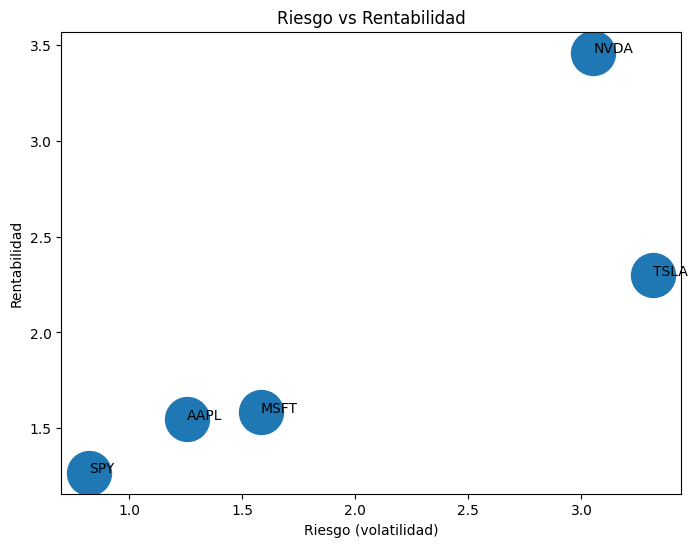

In [ ]:
plt.figure(figsize=(8,6))

# Eje X = riesgo (volatilidad), Eje Y = rentabilidad_final
# s = 1000 define el tamaño (size) de los puntos; los hace círculos grandes y visibles
plt.scatter(riesgo, rentabilidad_final, s = 1000) #scatter hace referencia a la grafica de puntos

for ticker in riesgo.index: #.index lo utilizamos para ver los nombres denro de el "diccionario" riesgo
    plt.text(riesgo[ticker], rentabilidad_final[ticker], ticker)
    # Colocamos el texto del ticker exactamente en sus coordenadas X e Y

plt.xlabel("Riesgo (volatilidad)")
plt.ylabel("Rentabilidad")
plt.title("Riesgo vs Rentabilidad")
plt.show()

* **Si tuvierais que recomendar una opción a un cliente conservador, ¿cuál elegiríais?**

 * **¿Y si fuera un cliente agresivo?**

Lo que acabamos de calcular con Python es esto:

![imagen](https://www.pimco.com/lat/es/-/media/global-assets/investment-strategies/bonds/pimco_bonds_esg_lat.webp?rev=144d3da641af495fb0bef07c14e55eda&h=1441&w=2560&la=es-419&hash=14E94DD4CB0A09513CFBE8B41D470207)

# **8. Construcción de TU Cartera**

##De elegir una acción a construir una estrategia

Hasta ahora hemos comparado activos individuales.
Pero en la vida real, nadie apuesta todo a una sola opción

Vamos a crear una cartera que reparta el dinero entre varios activos con el objetivo de reducir riesgo.

In [ ]:
pesos = {
    "AAPL": 0.3,
    "MSFT": 0.2,
    "SPY": 0.0,
    "TSLA": 0.1,
    "NVDA": 0.4
}

cartera = rentabilidad_acumulada.multiply(pesos).sum(axis=1) #La libreria pandas busca automaticamente el nombre de cada activo
#del diccionario "pesos" que coincida en "rentabilidad_acumulada" y lo suma todo (por columnas) en cartera

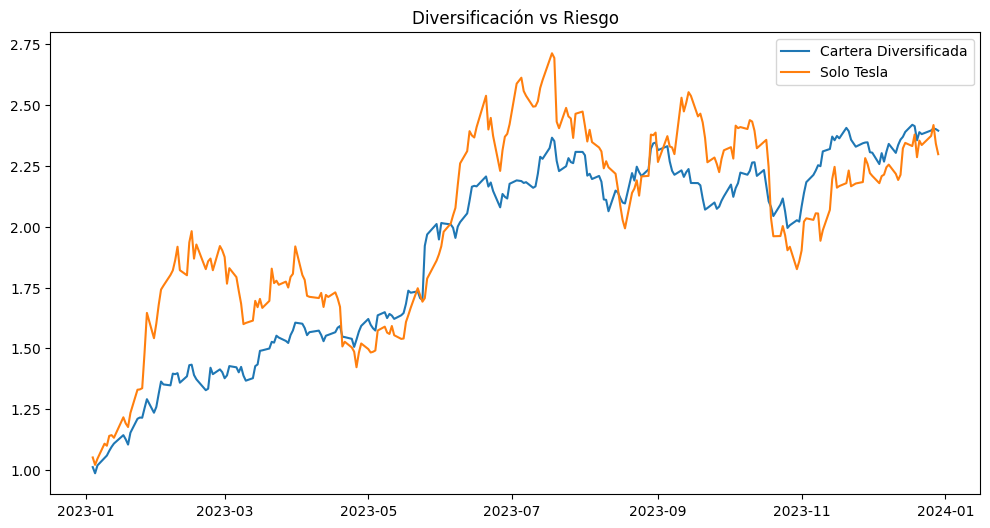

In [ ]:
plt.figure(figsize=(12,6)) #Tamaño de la figura (x =12, y=6)
plt.plot(cartera, label="Cartera Diversificada") #La linea de nuestra cartera, label seria su etiqueta
plt.plot(rentabilidad_acumulada["TSLA"], label="Solo Tesla") #Lo mismo con tesla, siemrpe promediado

plt.legend()#Muestra los labels
plt.title("Diversificación vs Riesgo")
plt.show()


In [ ]:
# Rendimientos diarios
rendimiento_tesla = rendimientos["TSLA"]
rendimiento_cartera = rendimientos.dot(pd.Series(pesos)) #.dot es un producto matricial que con los pesos de cada accion
# y los rendimientos totales crea un "Diccionario" (no es como tal pero lo tomamos asi de momento) con los rendimientos diarios

# Métricas anuales (x252 porque hay ~252 días de mercado)
rent_tesla = rendimiento_tesla.mean() * 252 #Promedio diario multiplicado por los dias del año
riesgo_tesla = rendimiento_tesla.std() * np.sqrt(252) #Riesgo = STD(anual)=(std(diaria)*252)^(1/2)
sharpe_tesla = rent_tesla / riesgo_tesla #Ratio sharpe mide cuanto ganas por ud de riesgo que asumes

rent_cartera = rendimiento_cartera.mean() * 252
riesgo_cartera = rendimiento_cartera.std() * np.sqrt(252)
sharpe_cartera = rent_cartera / riesgo_cartera

print("=== SOLO TESLA ===")
print("Rentabilidad anual:", round(rent_tesla * 100, 2), "%")
print("Riesgo (volatilidad):", round(riesgo_tesla * 100, 2), "%")
print("Sharpe Ratio:", round(sharpe_tesla, 2))

print("\n=== CARTERA DIVERSIFICADA ===")
print("Rentabilidad anual:", round(rent_cartera * 100, 2), "%")
print("Riesgo (volatilidad):", round(riesgo_cartera * 100, 2), "%")
print("Sharpe Ratio:", round(sharpe_cartera, 2))

=== SOLO TESLA ===
Rentabilidad anual: 98.1 %
Riesgo (volatilidad): 52.65 %
Sharpe Ratio: 1.86

=== CARTERA DIVERSIFICADA ===
Rentabilidad anual: 56.92 %
Riesgo (volatilidad): 20.05 %
Sharpe Ratio: 2.84


💡 Lo que acabamos de hacer en 10 minutos es lo que hacen los gestores profesionales para diseñar carteras. Python nos permite simular estrategias antes de arriesgar capital real

> Qué preferís vosotros?


# **9. Ahora pensamos como gestores**

##Por último, vamos a analizar nuestra cartera…



Ya no analizamos acciones aisladas.

Diseñamos una estrategia combinando activos con distintos pesos: **una cartera**  


Esto es exactamente lo que hacen:
- Fondos de inversión
- Gestores de patrimonios
- Bancos privados

Nuestro objetivo es responder a estas preguntas:

| Pregunta | Qué significa |
|--------|----------------|
| ¿Cuánto gana mi cartera? | Rentabilidad |
| ¿Cuánto riesgo tiene? | Volatilidad |
| ¿Compensa el riesgo? | Sharpe Ratio |

Vamos a calcular estas métricas usando datos reales de mercado.


In [ ]:
# Calculamos el rendimiento diario de la cartera
rendimiento_cartera = 0

for ticker in pesos:
    rendimiento_cartera += rendimientos[ticker] * pesos[ticker]

# Rentabilidad anual
rentabilidad_anual = rendimiento_cartera.mean() * 252 # Se elige 252 como constante de los días de bolsa al año.

# Riesgo anual (volatilidad)
riesgo_anual = rendimiento_cartera.std() * np.sqrt(252)

# Sharpe Ratio ;
sharpe = rentabilidad_anual / riesgo_anual #Se asume que la tasa libre de riesgo es 0

print("=== CARTERA ===")
print("Rentabilidad anual:", round(rentabilidad_anual * 100, 2), "%")
print("Riesgo:", round(riesgo_anual * 100, 2), "%")
print("Sharpe Ratio:", round(sharpe, 2))


=== CARTERA ===
Rentabilidad anual: 56.92 %
Riesgo: 20.05 %
Sharpe Ratio: 2.84


💡Lo potente de Python es que podemos cambiar los pesos en segundos y simular nuevas estrategias antes de invertir dinero real.

**En lugar de apostar, estamos diseñando.
Y eso es la diferencia entre intuición y estrategia.**

Para cerrar, hoy no hemos aprendido simplemente a usar Python.
Hoy hemos hecho algo que en empresa es fundamental:
cuestionar la intuición y validar con datos.

Hemos visto que:

- La rentabilidad sin contexto puede engañar.

- El riesgo importa tanto como el beneficio.
- Y que una buena estrategia no es apostar, es diseñar.

Esperamos que hoy os llevéis no solo herramientas técnicas,
sino una nueva forma de pensar las decisiones.

Python no es el objetivo.
Es el medio para pensar mejor.

Deseamos que salgáis de aquí con curiosidad, con ganas de experimentar
y con la sensación de que estas herramientas están a vuestro alcance.

#**¡Muchas gracias por venir a este evento!**